## Mount Google Drive

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Create Project  Folder Structure

In [28]:
import os

ROOT = "/content/drive/MyDrive/rl-loop-agent"

folders = [
    "env",
    "rewards",
    "train",
    "output/models",
    "output/plots",
    "output/results"
]

for f in folders:
    os.makedirs(f"{ROOT}/{f}", exist_ok=True)

print("Folders created")

Folders created


## Install Required Libraries

In [29]:
!pip install gymnasium stable-baselines3 matplotlib numpy

## Create __init__.py Files

In [30]:
open(f"{ROOT}/env/__init__.py","w").close()
open(f"{ROOT}/rewards/__init__.py","w").close()
open(f"{ROOT}/train/__init__.py","w").close()

print("Init files created")

Init files created


## Create the Reward Function

In [31]:
code = '''
def compute_reward(node, action):

    size = node["size"]
    parallelizable = node["parallelizable"]
    loop_carried = node["loop_carried_count"]

    instruction_cost = size * 2.0
    cache_miss_penalty = loop_carried * 3.0

    if action == 1:

        if parallelizable:
            reward = 5.0 - (instruction_cost * 0.1)
        else:
            reward = 2.0 - (cache_miss_penalty * 0.2)

    else:

        if parallelizable:
            reward = -2.0
        else:
            reward = 1.0 - (instruction_cost * 0.05)

    return reward
'''

with open(f"{ROOT}/rewards/reward_function.py","w") as f:
    f.write(code)

print("reward_function.py created")

reward_function.py created


## Create the RL Environment

In [32]:
code = '''
import gymnasium as gym
import numpy as np
import json
from rewards.reward_function import compute_reward

class LoopDistributionEnv(gym.Env):

    def __init__(self, sdg_json):

        with open(sdg_json) as f:
            data = json.load(f)

        self.nodes = data["nodes"]
        self.node_labels = [n["id"] for n in self.nodes]

        self.index = 0

        self.observation_space = gym.spaces.Box(
            low=0,
            high=100,
            shape=(4,),
            dtype=np.float32
        )

        self.action_space = gym.spaces.Discrete(2)

    def reset(self, seed=None, options=None):

        self.index = 0
        return self._get_state(), {}

    def _get_state(self):

        node = self.nodes[self.index]

        return np.array([
            node["size"],
            int(node["parallelizable"]),
            node["loop_carried_count"],
            self.index / len(self.nodes)
        ], dtype=np.float32)

    def step(self, action):

        node = self.nodes[self.index]

        reward = compute_reward(node, action)

        self.index += 1

        done = self.index >= len(self.nodes)

        if done:
            next_state = np.zeros(4)
        else:
            next_state = self._get_state()

        return next_state, reward, done, False, {}
'''

with open(f"{ROOT}/env/loop_env.py","w") as f:
    f.write(code)

print("loop_env.py created")

loop_env.py created


## Create the Trainer

In [33]:
code = '''
import os
import json
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from env.loop_env import LoopDistributionEnv


def train_agent(sdg_file, output_dir):

    env = LoopDistributionEnv(sdg_file)

    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        learning_rate=0.0003
    )

    rewards = []

    for episode in range(200):

        model.learn(total_timesteps=50)

        obs,_ = env.reset()

        total_reward = 0

        while True:

            action,_ = model.predict(obs)

            obs,reward,done,_,_ = env.step(action)

            total_reward += reward

            if done:
                break

        rewards.append(total_reward)

    name = os.path.basename(sdg_file).replace("_sdg.json","")

    model.save(f"{output_dir}/models/{name}_ppo")

    plot_reward_curve(rewards,name,output_dir)

    env = LoopDistributionEnv(sdg_file)

    rl_results = evaluate_model(model,env)

    env = LoopDistributionEnv(sdg_file)

    no_opt_reward,_ = no_opt_agent(env)

    env = LoopDistributionEnv(sdg_file)

    split_reward,_ = always_split_agent(env)

    save_results(name,rl_results,no_opt_reward,split_reward,output_dir)

    plot_comparison(name,no_opt_reward,split_reward,rl_results["total_reward"],output_dir)

    return model


def evaluate_model(model,env):

    obs,_ = env.reset()

    total_reward = 0
    plan = []

    node_index = 0

    while True:

        action,_ = model.predict(obs)

        obs,reward,done,_,_ = env.step(action)

        label = env.node_labels[node_index]

        decision = "SPLIT" if action==1 else "KEEP"

        plan.append({"node":label,"action":decision})

        total_reward += reward

        node_index += 1

        if done:
            break

    return {"total_reward":float(total_reward),"distribution_plan":plan}


def no_opt_agent(env):

    obs,_ = env.reset()

    total_reward = 0
    plan = []

    node_index = 0

    while True:

        action = 0

        obs,reward,done,_,_ = env.step(action)

        label = env.node_labels[node_index]

        plan.append({"node":label,"action":"KEEP"})

        total_reward += reward

        node_index += 1

        if done:
            break

    return total_reward,plan


def always_split_agent(env):

    obs,_ = env.reset()

    total_reward = 0
    plan = []

    node_index = 0

    while True:

        action = 1

        obs,reward,done,_,_ = env.step(action)

        label = env.node_labels[node_index]

        plan.append({"node":label,"action":"SPLIT"})

        total_reward += reward

        node_index += 1

        if done:
            break

    return total_reward,plan


def plot_reward_curve(rewards,name,output_dir):

    plt.figure()

    plt.plot(rewards)

    plt.title(f"Training Reward — {name}")

    plt.xlabel("Episode")

    plt.ylabel("Reward")

    plt.savefig(f"{output_dir}/plots/{name}_reward.png")

    plt.close()


def plot_comparison(name,no_opt,split,rl,output_dir):

    labels = ["No Optimization","Always Split","RL Agent"]

    values = [no_opt,split,rl]

    plt.figure()

    plt.bar(labels,values,color=["red","orange","green"])

    plt.title(f"Strategy Comparison — {name}")

    plt.ylabel("Total Reward")

    plt.savefig(f"{output_dir}/plots/{name}_comparison.png")

    plt.close()


def save_results(loop_name,rl_results,no_opt,split,output_dir):

    results = {
        "loop":loop_name,
        "no_opt_reward":no_opt,
        "split_reward":split,
        "rl_reward":rl_results["total_reward"],
        "distribution_plan":rl_results["distribution_plan"]
    }

    path = f"{output_dir}/results/{loop_name}_results.json"

    with open(path,"w") as f:
        json.dump(results,f,indent=4)
'''

with open(f"{ROOT}/train/trainer.py","w") as f:
    f.write(code)

print("trainer.py updated")

trainer.py updated


## Load SDG Files from Project 1

In [34]:
import sys
sys.path.append(ROOT)

import glob
from train.trainer import train_agent

SDG_PATH = "/content/drive/MyDrive/sdg-loop-distribution/output/graphs"

sdg_files = glob.glob(f"{SDG_PATH}/*_sdg.json")

print("SDG files found:",sdg_files)

for f in sdg_files:

    print("Training on:",f)

    train_agent(f,ROOT+"/output")

SDG files found: ['/content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_parallel_sdg.json', '/content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_carried_sdg.json', '/content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_mixed_sdg.json', '/content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_complex_sdg.json', '/content/drive/MyDrive/sdg-loop-distribution/output/graphs/example_loop_sdg.json']
Training on: /content/drive/MyDrive/sdg-loop-distribution/output/graphs/loop_parallel_sdg.json
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3        |
|    ep_rew_mean     | 3.66     |
| time/              |          |
|    fps             | 2106     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------

## Comparison Chart

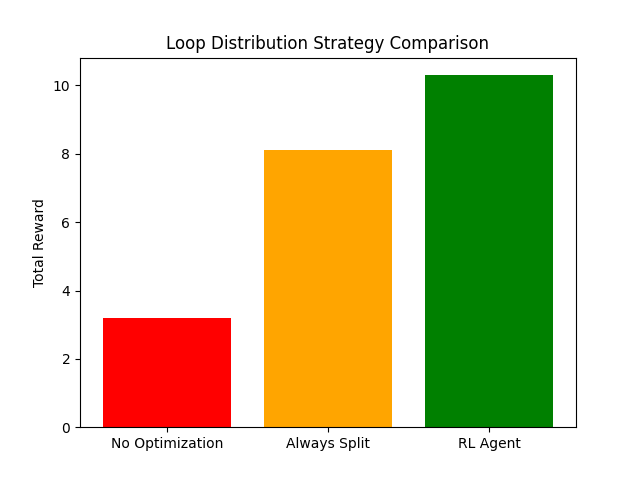

In [35]:
import os
from IPython.display import Image,display

plot_dir = ROOT+"/output/plots"

for f in os.listdir(plot_dir):

    if "comparison" in f:

        display(Image(filename=os.path.join(plot_dir,f)))